# 🧠 Brain Tumor Patient Survival Time Prediction

### Machine Learning Regression Project

This project predicts patient survival time using clinical and treatment-related features from a brain tumor dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [12]:
data = pd.read_csv("BrainTumor.csv")

data.head(15)

,Patient ID,Age,Gender,Tumor Type,Tumor Grade,Tumor Location,Treatment,Treatment Outcome,Time to Recurrence (months),Recurrence Site,Survival Time (months)
0,1,45,Male,Glioblastoma,IV,Frontal lobe,Surgery,Partial response,10.0,Temporal lobe,18
1,2,55,Female,Meningioma,I,Parietal lobe,Surgery,Complete response,NaN,NaN,36
2,3,60,Male,Astrocytoma,III,Occipital lobe,Surgery + Chemotherapy,Progressive disease,14.0,Frontal lobe,22
3,4,50,Female,Glioblastoma,IV,Temporal lobe,Surgery + Radiation therapy,Complete response,NaN,NaN,12
4,5,65,Male,Astrocytoma,II,Frontal lobe,Surgery + Radiation therapy,Partial response,24.0,Frontal lobe,48
5,6,45,Male,Glioblastoma,IV,Frontal lobe,Surgery,Partial response,10.0,Temporal lobe,18
6,7,55,Female,Meningioma,I,Parietal lobe,Surgery,Complete response,NaN,NaN,36
7,8,60,Male,Astrocytoma,III,Occipital lobe,Surgery + Chemotherapy,Progressive disease,14.0,Frontal lobe,22
8,9,50,Female,Glioblastoma,IV,Temporal lobe,Surgery + Radiation,Complete response,NaN,NaN,12
9,10,65,Male,Astrocytoma,II,Frontal lobe,Surgery + Radiation,Partial response,24.0,Frontal lobe,48


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Patient ID                   2000 non-null   int64  
 1   Age                          2000 non-null   int64  
 2   Gender                       2000 non-null   object 
 3   Tumor Type                   2000 non-null   object 
 4   Tumor Grade                  2000 non-null   object 
 5   Tumor Location               2000 non-null   object 
 6   Treatment                    2000 non-null   object 
 7   Treatment Outcome            2000 non-null   object 
 8   Time to Recurrence (months)  1438 non-null   float64
 9   Recurrence Site              1438 non-null   object 
 10  Survival Time (months)       2000 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 172.0+ KB


In [6]:
data.shape

(2000, 11)

In [7]:
data.columns

Index(['Patient ID', 'Age', 'Gender', 'Tumor Type', 'Tumor Grade',
       'Tumor Location', 'Treatment', 'Treatment Outcome',
       'Time to Recurrence (months)', 'Recurrence Site',
       'Survival Time (months)'],
      dtype='object')

In [8]:
data.describe

<bound method NDFrame.describe of       Patient ID  Age  Gender    Tumor Type Tumor Grade  Tumor Location  \
0              1   45    Male  Glioblastoma          IV    Frontal lobe   
1              2   55  Female    Meningioma           I   Parietal lobe   
2              3   60    Male   Astrocytoma         III  Occipital lobe   
3              4   50  Female  Glioblastoma          IV   Temporal lobe   
4              5   65    Male   Astrocytoma          II    Frontal lobe   
...          ...  ...     ...           ...         ...             ...   
1995        1996   49  Female    Meningioma           I   Parietal lobe   
1996        1997   57    Male  Glioblastoma          IV  Occipital lobe   
1997        1998   45  Female    Meningioma           I   Temporal lobe   
1998        1999   62    Male   Astrocytoma         III    Frontal lobe   
1999        2000   53  Female  Glioblastoma          IV   Parietal lobe   

                        Treatment    Treatment Outcome  \
0      

In [16]:
data.isnull().sum()

Patient ID                       0
Age                              0
Gender                           0
Tumor Type                       0
Tumor Grade                      0
Tumor Location                   0
Treatment                        0
Treatment Outcome                0
Time to Recurrence (months)    562
Recurrence Site                562
Survival Time (months)           0
dtype: int64

In [17]:
missing_percentage = (data.isnull().sum() / len(data))*100
missing_percentage

Patient ID                      0.0
Age                             0.0
Gender                          0.0
Tumor Type                      0.0
Tumor Grade                     0.0
Tumor Location                  0.0
Treatment                       0.0
Treatment Outcome               0.0
Time to Recurrence (months)    28.1
Recurrence Site                28.1
Survival Time (months)          0.0
dtype: float64

In [22]:
data.dropna()

,Patient ID,Age,Gender,Tumor Type,Tumor Grade,Tumor Location,Treatment,Treatment Outcome,Time to Recurrence (months),Recurrence Site,Survival Time (months)
0,1,45,Male,Glioblastoma,IV,Frontal lobe,Surgery,Partial response,10.0,Temporal lobe,18
2,3,60,Male,Astrocytoma,III,Occipital lobe,Surgery + Chemotherapy,Progressive disease,14.0,Frontal lobe,22
4,5,65,Male,Astrocytoma,II,Frontal lobe,Surgery + Radiation therapy,Partial response,24.0,Frontal lobe,48
5,6,45,Male,Glioblastoma,IV,Frontal lobe,Surgery,Partial response,10.0,Temporal lobe,18
7,8,60,Male,Astrocytoma,III,Occipital lobe,Surgery + Chemotherapy,Progressive disease,14.0,Frontal lobe,22
...,...,...,...,...,...,...,...,...,...,...,...
1994,1995,64,Male,Astrocytoma,III,Frontal lobe,Chemotherapy,Stable disease,14.0,Frontal lobe,26
1995,1996,49,Female,Meningioma,I,Parietal lobe,Radiation,Progressive disease,18.0,Parietal lobe,32
1997,1998,45,Female,Meningioma,I,Temporal lobe,Chemotherapy,Partial response,20.0,Temporal lobe,44
1998,1999,62,Male,Astrocytoma,III,Frontal lobe,Radiation,Stable disease,22.0,Frontal lobe,28


In [23]:
missing_percentage = (data.isnull().sum() /len(data))*100
missing_percentage

Patient ID                      0.0
Age                             0.0
Gender                          0.0
Tumor Type                      0.0
Tumor Grade                     0.0
Tumor Location                  0.0
Treatment                       0.0
Treatment Outcome               0.0
Time to Recurrence (months)    28.1
Recurrence Site                28.1
Survival Time (months)          0.0
dtype: float64

In [25]:
print("Numerical Columns:")
print(data.select_dtypes(include=np.number).columns)

print("\nCategorical Columns:")
print(data.select_dtypes(include="object").columns)

Numerical Columns:
Index(['Patient ID', 'Age', 'Time to Recurrence (months)',
       'Survival Time (months)'],
      dtype='object')

Categorical Columns:
Index(['Gender', 'Tumor Type', 'Tumor Grade', 'Tumor Location', 'Treatment',
       'Treatment Outcome', 'Recurrence Site'],
      dtype='object')


In [26]:
data.describe()

,Patient ID,Age,Time to Recurrence (months),Survival Time (months)
count,2000.000000,2000.000000,1438.000000,2000.000000
mean,1000.500000,56.153000,16.099444,34.270000
std,577.494589,6.078492,3.128291,8.606343
min,1.000000,42.000000,6.000000,9.000000
25%,500.750000,51.000000,14.000000,28.000000
50%,1000.500000,56.000000,16.000000,36.000000
75%,1500.250000,61.000000,18.000000,42.000000
max,2000.000000,72.000000,36.000000,72.000000


In [27]:
categorical_columns = data.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(data[column].value_counts())


Gender:
Gender
Female    1007
Male       993
Name: count, dtype: int64

Tumor Type:
Tumor Type
Meningioma      710
Astrocytoma     653
Glioblastoma    637
Name: count, dtype: int64

Tumor Grade:
Tumor Grade
I      710
IV     635
II     349
III    306
Name: count, dtype: int64

Tumor Location:
Tumor Location
Frontal lobe      515
Parietal lobe     503
Temporal lobe     497
Occipital lobe    485
Name: count, dtype: int64

Treatment:
Treatment
Surgery + Radiation            882
Surgery + Chemotherapy         779
Surgery                        139
Chemotherapy                   123
Radiation                       73
Surgery + Radiation therapy      2
Chemotherapy + Radiation         2
Name: count, dtype: int64

Treatment Outcome:
Treatment Outcome
Progressive disease    582
Complete response      561
Stable disease         504
Partial response       353
Name: count, dtype: int64

Recurrence Site:
Recurrence Site
Frontal lobe      414
Temporal lobe     381
Parietal lobe     367
Occipital l

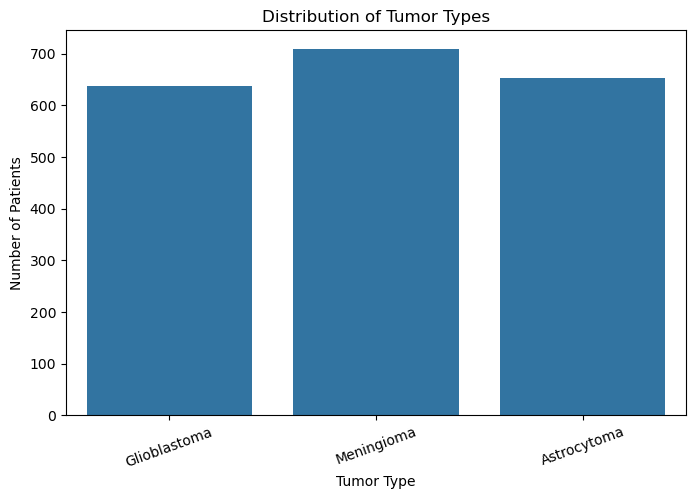

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x="Tumor Type")

plt.title("Distribution of Tumor Types")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)

plt.show()

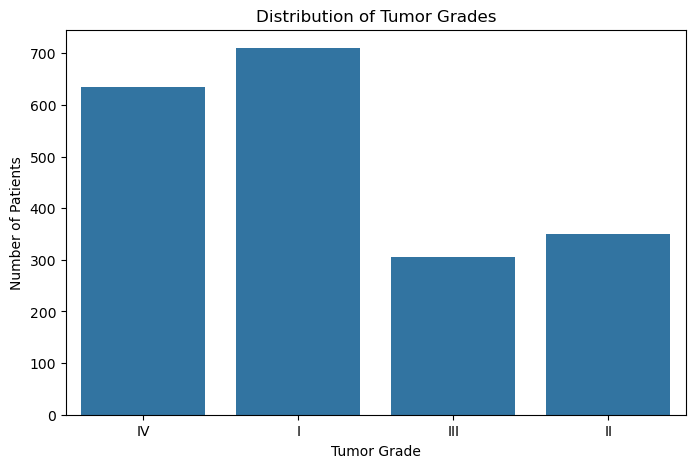

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x="Tumor Grade")

plt.title("Distribution of Tumor Grades")
plt.xlabel("Tumor Grade")
plt.ylabel("Number of Patients")

plt.show()

In [30]:
data["Tumor Grade"].value_counts()

Tumor Grade
I      710
IV     635
II     349
III    306
Name: count, dtype: int64

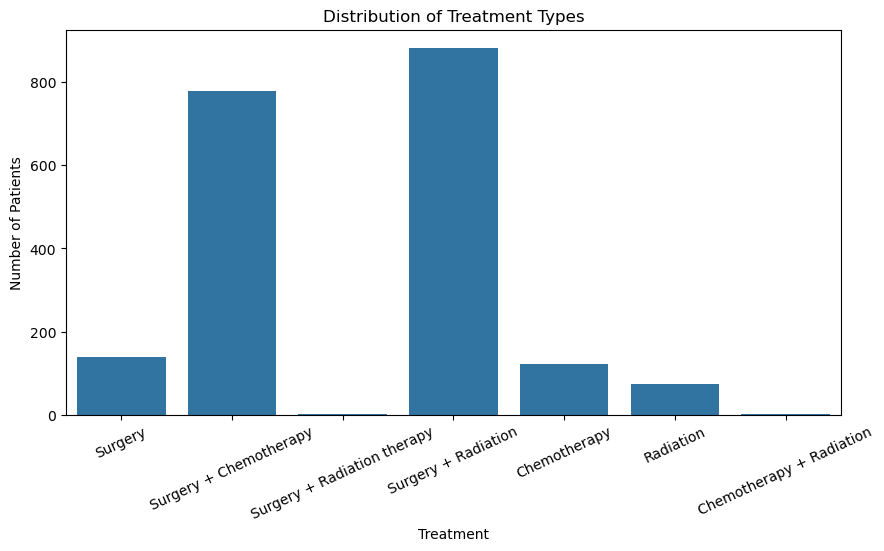

In [31]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data, x="Treatment")

plt.title("Distribution of Treatment Types")
plt.xlabel("Treatment")
plt.ylabel("Number of Patients")
plt.xticks(rotation=25)

plt.show()

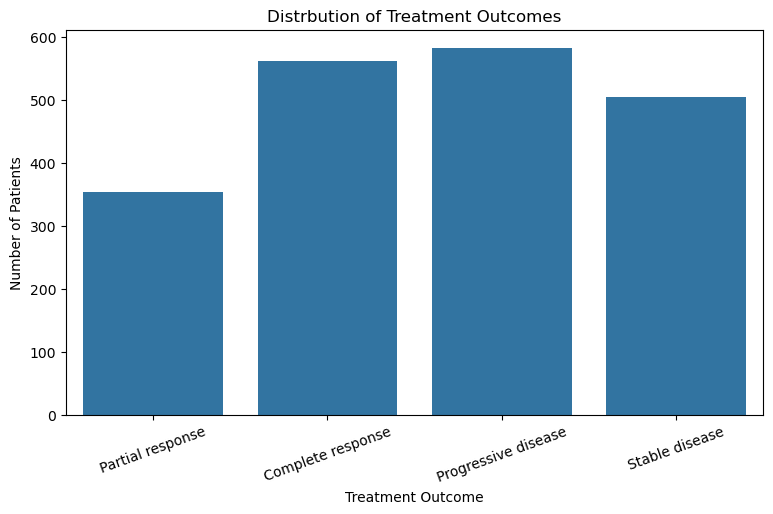

In [32]:
plt.figure(figsize=(9,5))

sns.countplot(data=data, x="Treatment Outcome")

plt.title("Distrbution of Treatment Outcomes")
plt.xlabel("Treatment Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)

plt.show()

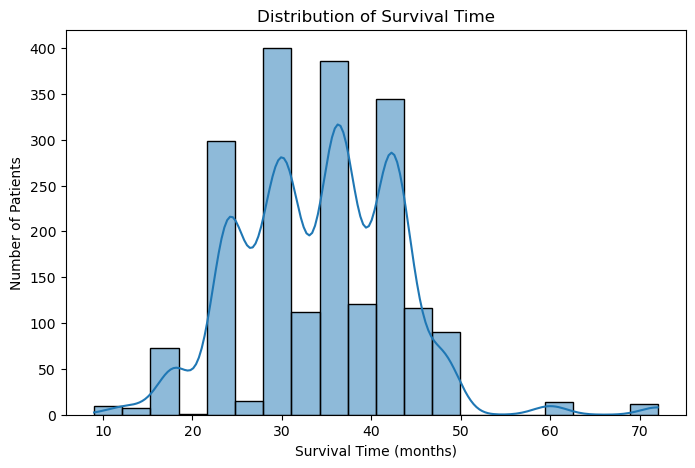

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(data["Survival Time (months)"], bins=20, kde=True)

plt.title("Distribution of Survival Time")
plt.xlabel("Survival Time (months)")
plt.ylabel("Number of Patients")

plt.show()

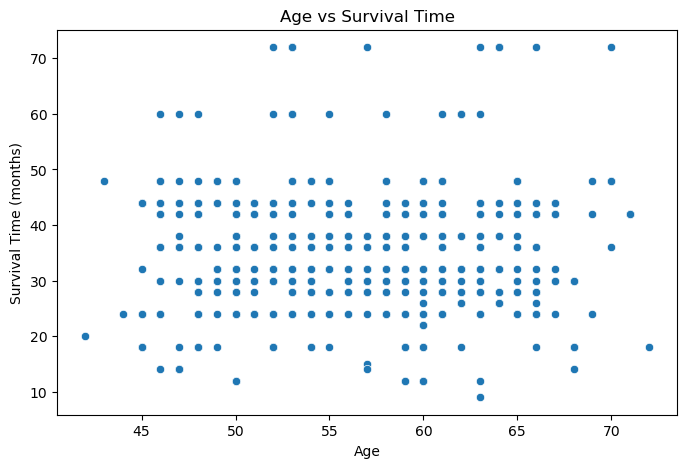

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Age",
    y="Survival Time (months)"
)

plt.title("Age vs Survival Time")
plt.xlabel("Age")
plt.ylabel("Survival Time (months)")

plt.show()

In [35]:
data[["Age", "Survival Time (months)"]].corr()

,Age,Survival Time (months)
Age,1.000000,0.066282
Survival Time (months),0.066282,1.000000


In [36]:
correlation = data.select_dtypes(include=np.number).corr()

correlation

,Patient ID,Age,Time to Recurrence (months),Survival Time (months)
Patient ID,1.000000,-0.009721,0.075942,-0.016479
Age,-0.009721,1.000000,0.015541,0.066282
Time to Recurrence (months),0.075942,0.015541,1.000000,0.419362
Survival Time (months),-0.016479,0.066282,0.419362,1.000000


# Heatmap

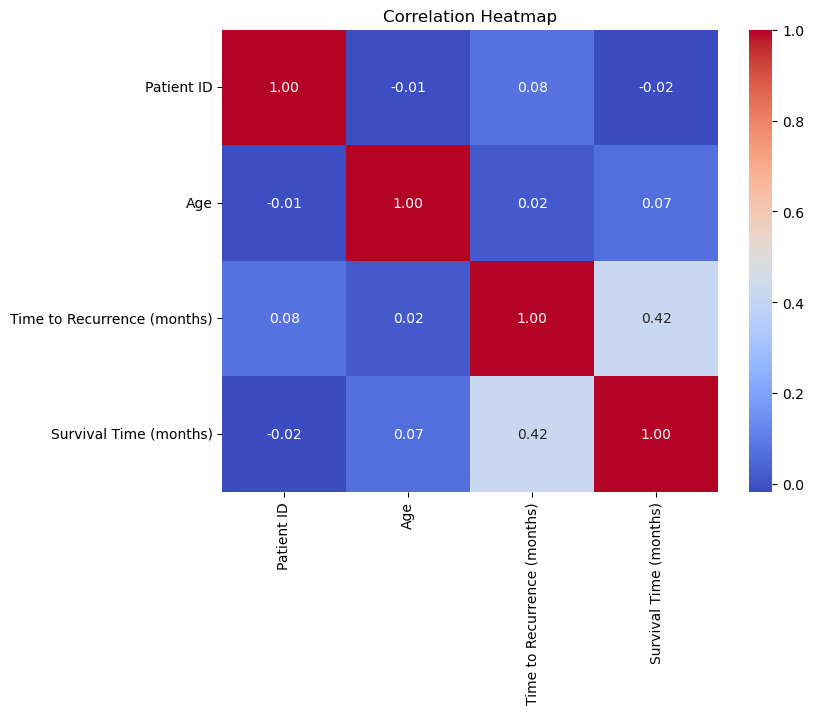

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
data["Time to Recurrence (months)"].median()

16.0

In [44]:
data["Time to Recurrence (months)"] = data["Time to Recurrence (months)"].fillna(
    data["Time to Recurrence (months)"].median()
)

In [45]:
data["Recurrence Site"] = data["Recurrence Site"].fillna("Unknown")

In [46]:
data.isnull().sum()

Patient ID                     0
Age                            0
Gender                         0
Tumor Type                     0
Tumor Grade                    0
Tumor Location                 0
Treatment                      0
Treatment Outcome              0
Time to Recurrence (months)    0
Recurrence Site                0
Survival Time (months)         0
dtype: int64

In [47]:
X = data.drop(columns=["Patient ID", "Survival Time (months)"])
y = data["Survival Time (months)"]

In [48]:
"Patient ID"

'Patient ID'

In [49]:
"Survival Time (months)"

'Survival Time (months)'

In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 9)
y shape: (2000,)


# Catogorical Encoding

In [51]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [52]:
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (2000, 9)
Encoded X shape: (2000, 24)


In [53]:
X_encoded.head()


,Age,Time to Recurrence (months),Gender_Male,Tumor Type_Glioblastoma,Tumor Type_Meningioma,Tumor Grade_II,Tumor Grade_III,Tumor Grade_IV,Tumor Location_Occipital lobe,Tumor Location_Parietal lobe,...,Treatment_Surgery + Chemotherapy,Treatment_Surgery + Radiation,Treatment_Surgery + Radiation therapy,Treatment Outcome_Partial response,Treatment Outcome_Progressive disease,Treatment Outcome_Stable disease,Recurrence Site_Occipital lobe,Recurrence Site_Parietal lobe,Recurrence Site_Temporal lobe,Recurrence Site_Unknown
0,45,10.0,True,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
1,55,16.0,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,60,14.0,True,False,False,False,True,False,True,False,...,True,False,False,False,True,False,False,False,False,False
3,50,16.0,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
4,65,24.0,True,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False


In [54]:
X_encoded = X_encoded.astype(int)

In [55]:
X_encoded.head()

,Age,Time to Recurrence (months),Gender_Male,Tumor Type_Glioblastoma,Tumor Type_Meningioma,Tumor Grade_II,Tumor Grade_III,Tumor Grade_IV,Tumor Location_Occipital lobe,Tumor Location_Parietal lobe,...,Treatment_Surgery + Chemotherapy,Treatment_Surgery + Radiation,Treatment_Surgery + Radiation therapy,Treatment Outcome_Partial response,Treatment Outcome_Progressive disease,Treatment Outcome_Stable disease,Recurrence Site_Occipital lobe,Recurrence Site_Parietal lobe,Recurrence Site_Temporal lobe,Recurrence Site_Unknown
0,45,10,1,1,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
1,55,16,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,60,14,1,0,0,0,1,0,1,0,...,1,0,0,0,1,0,0,0,0,0
3,50,16,0,1,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
4,65,24,1,0,0,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [56]:
X_encoded = X_encoded.astype(int)

In [57]:
print(X_encoded.dtypes.value_counts())

int64    24
Name: count, dtype: int64


# Train

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1600, 24)
X_test: (400, 24)
y_train: (1600,)
y_test: (400,)


# Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
scaler.fit_transform(X_train)

array([[-0.17810934,  0.73862053, -0.98757716, ..., -0.47248449,
        -0.48235427, -0.63328571],
       [-1.00700678, -0.01821126, -0.98757716, ..., -0.47248449,
        -0.48235427,  1.57906611],
       [-1.67012473,  0.73862053, -0.98757716, ..., -0.47248449,
         2.07316503, -0.63328571],
       ...,
       [-0.6754478 , -0.77504306, -0.98757716, ..., -0.47248449,
        -0.48235427, -0.63328571],
       [ 1.14812656, -0.77504306, -0.98757716, ..., -0.47248449,
        -0.48235427, -0.63328571],
       [ 0.6507881 , -0.01821126, -0.98757716, ..., -0.47248449,
        -0.48235427,  1.57906611]], shape=(1600, 24))

In [62]:
scaler.transform(X_test)

array([[-0.84122729, -0.01821126, -0.98757716, ..., -0.47248449,
        -0.48235427,  1.57906611],
       [-0.6754478 ,  0.73862053,  1.01257911, ..., -0.47248449,
        -0.48235427, -0.63328571],
       [ 0.15344964, -0.01821126,  1.01257911, ..., -0.47248449,
        -0.48235427,  1.57906611],
       ...,
       [ 1.47968554, -1.53187485, -0.98757716, ..., -0.47248449,
        -0.48235427, -0.63328571],
       [-0.6754478 ,  1.49545232,  1.01257911, ..., -0.47248449,
         2.07316503, -0.63328571],
       [-0.84122729, -0.01821126, -0.98757716, ...,  2.11647161,
        -0.48235427, -0.63328571]], shape=(400, 24))

In [63]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1600, 24)
X_test_scaled shape: (400, 24)


#  ML Model

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred = model.predict(X_test_scaled)

In [66]:
print(y_pred[:10])

[36.46854584 31.05804787 38.08028292 34.01484153 36.96893807 28.1379506
 36.68730591 27.93992021 41.56602109 28.1379506 ]


In [67]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,36,36.468546
1,36,31.058048
2,38,38.080283
3,30,34.014842
4,38,36.968938
5,32,28.137951
6,36,36.687306
7,42,27.939920
8,36,41.566021
9,32,28.137951


# MAE

In [68]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 5.286933768879715


In [69]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 47.47041963680018


In [70]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 6.889878056743833


# R² Score

In [71]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.3777790350377933


# Actual vs Predicted Graph

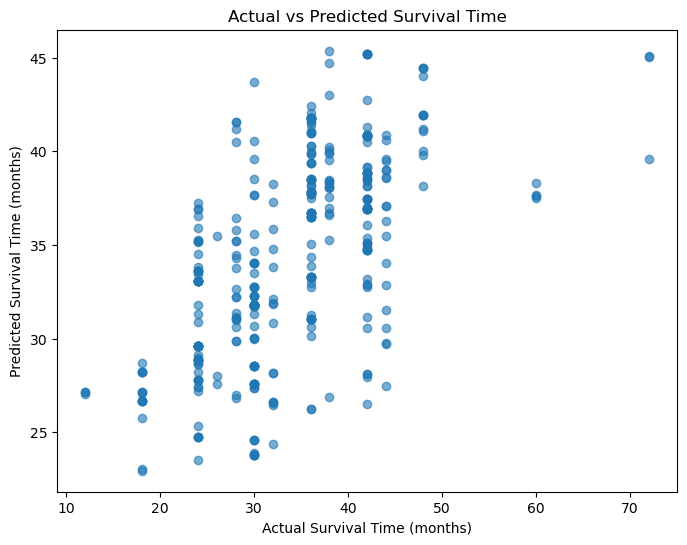

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Survival Time (months)")
plt.ylabel("Predicted Survival Time (months)")
plt.title("Actual vs Predicted Survival Time")

plt.show()

# Random Forest

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[36.         36.         38.03       30.         41.014275   30.17
 36.17627699 37.63       37.775      30.17      ]


# MAE, MSE, RMSE R² of Random Forest 

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.5058504978083278
Random Forest MSE: 14.049849904461016
Random Forest RMSE: 3.7483129411057736
Random Forest R²: 0.8158408703353697


# Linear Regression vs Random Forest

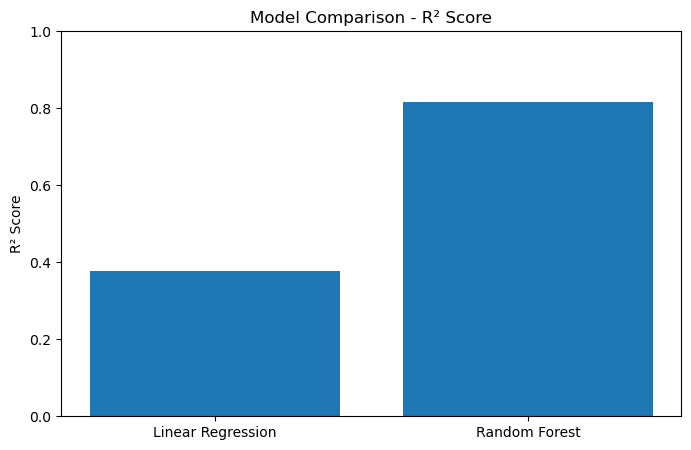

In [76]:
models = ["Linear Regression", "Random Forest"]

r2_scores = [r2, rf_r2]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.ylim(0, 1)

plt.show()

# 🧠 Random Forest Feature Importance for Brain Tumor Prediction

In [77]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Time to Recurrence (months),0.228585
0,Age,0.212122
23,Recurrence Site_Unknown,0.120592
10,Tumor Location_Temporal lobe,0.068638
2,Gender_Male,0.040042
8,Tumor Location_Occipital lobe,0.031286
14,Treatment_Surgery + Chemotherapy,0.029278
4,Tumor Type_Meningioma,0.028591
19,Treatment Outcome_Stable disease,0.026704
20,Recurrence Site_Occipital lobe,0.026399


# Graph of Feature Importance

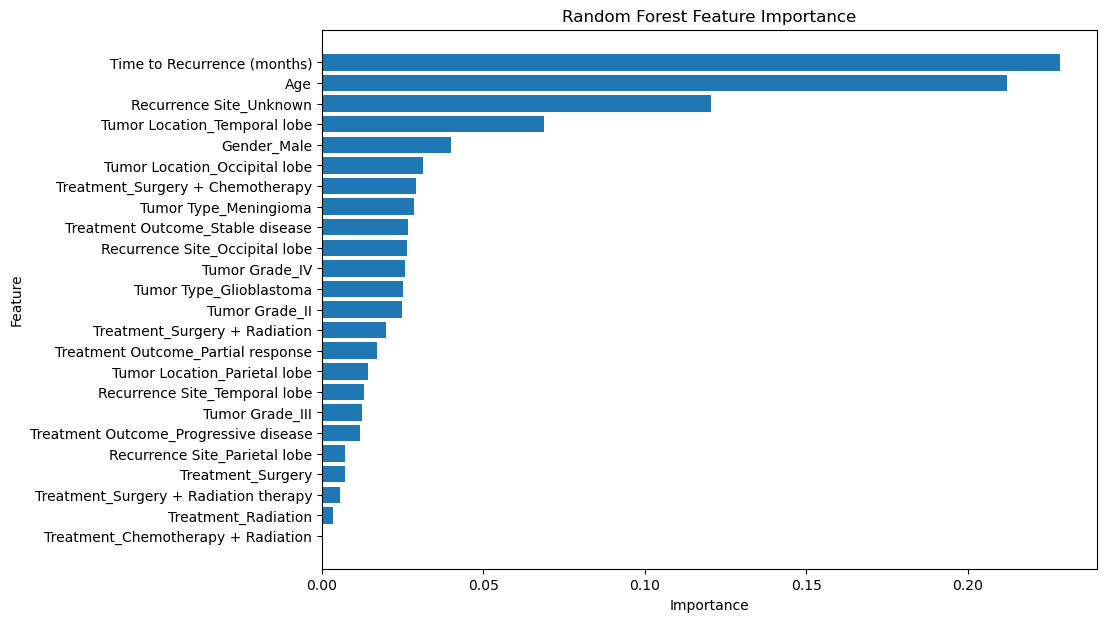

In [78]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Random Forest Actual vs Predicted

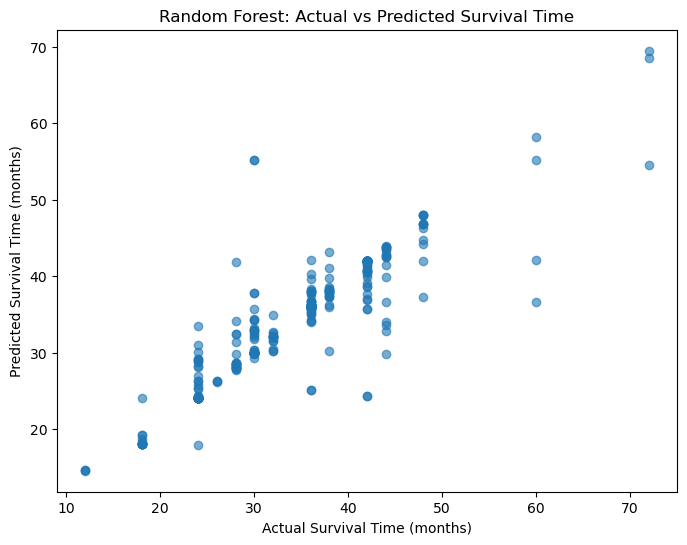

In [79]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Survival Time (months)")
plt.ylabel("Predicted Survival Time (months)")
plt.title("Random Forest: Actual vs Predicted Survival Time")

plt.show()

# Metrics Comparison Table: Linear Regression vs Random Forest


In [80]:
comparison_metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

comparison_metrics

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,5.286934,47.47042,6.889878,0.377779
1,Random Forest,1.505850,14.04985,3.748313,0.815841


# Conclusion

This project developed a machine learning model to predict brain tumor patient survival time using clinical and treatment-related features.

Two regression models were evaluated:

- Linear Regression
- Random Forest Regressor

The Random Forest model performed substantially better than Linear Regression on the test dataset.

## Results

| Model | MAE | MSE | RMSE | R² |
|------|-----|-----|------|-----|
| Linear Regression | 5.29 | 47.47 | 6.89 | 0.378 |
| Random Forest | 1.51 | 14.05 | 3.75 | 0.816 |

The Random Forest achieved an R² score of 0.816 on the test dataset, with an MAE of approximately 1.51 months.

Feature importance analysis showed that Time to Recurrence, Age, and Recurrence Site information were among the most influential predictive features.

> Note: This project is intended for machine learning education and experimentation. It should not be used for medical diagnosis, prognosis, or treatment decisions.